# Get Semantic Segmentations from real data

We will get the SS from the images taken by the VW car with 3 cameras: 60, 120, and 180° FOV.

In [1]:
import data_analysis.data_tools as dtools
from transformers.models.mask2former import modeling_mask2former, image_processing_mask2former
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation
import torch

from _utils import utils
import os

/home/dporres/miniconda3/envs/cilv2-icrea/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ["CUDA_VISIBLE_DEVICES"] = '4'
device = 'cuda' if torch.cuda.is_available() else device

model_name = "facebook/mask2former-swin-large-mapillary-vistas-semantic"
processor = AutoImageProcessor.from_pretrained(model_name)
model = Mask2FormerForUniversalSegmentation.from_pretrained(model_name).to(device)
model.eval()

Mask2FormerForUniversalSegmentation(
  (model): Mask2FormerModel(
    (pixel_level_module): Mask2FormerPixelLevelModule(
      (encoder): SwinBackbone(
        (embeddings): SwinEmbeddings(
          (patch_embeddings): SwinPatchEmbeddings(
            (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
          )
          (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (encoder): SwinEncoder(
          (layers): ModuleList(
            (0): SwinStage(
              (blocks): ModuleList(
                (0): SwinLayer(
                  (layernorm_before): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
                  (attention): SwinAttention(
                    (self): SwinSelfAttention(
                      (query): Linear(in_features=192, out_features=192, bias=True)
                      (key): Linear(in_features=192, out_features=192, bias=True)
                      (valu

In [3]:
!ls /data/122-2/Datasets/IL_multiview

60_120_180
60_120_180_roundabout2
60_120_180_roundabout2_contis
60_120_180_roundabout2_contis_shifted_200ms
60_120_180_roundabout2_shifted_100ms
60_120_180_roundabout2_shifted_200ms
60_120_180_roundabout2_shifted_200ms_filtered
60_120_180_sobj
60_120_180_sobj_s200ms
60_120_180_stopping_objects
60_120_180_stopping_objects_shifted_200ms
lane_endtoend_prediction
lane_prediction
lane_prediction_subset
sekonix2_contis3
sekonix2_contis3_200ms
small_test
TED
test
to_remove


In [4]:
dataset_path = '/data/122-2/Datasets/IL_multiview/60_120_180_roundabout2_shifted_200ms_filtered/18-abr-23/uab_cloudy/'
rgb_prefixes = ['sekonix_60']

image_paths = dtools.get_files_with_prefix_and_suffix(dataset_path, rgb_prefixes, '.png')
utils.sort_nicely(image_paths)
total_images = len(image_paths)
print(total_images)

Scanning directories: 100%|██████████| 2/2 [00:00<00:00,  2.46it/s]


76767


In [5]:
ss = dtools.predict_segmentation(
    image_path=image_paths[0],
    processor=processor,
    model=model,
    device=device
)

In [6]:
ss.shape

(362, 576)

In [7]:
rgb_ss = dtools.mapillary_to_cityscapes_rgb(ss)

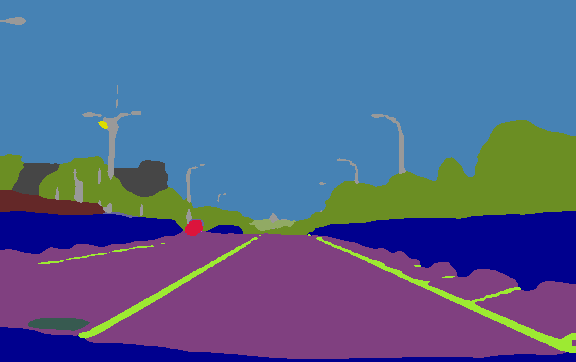

In [8]:
from PIL import Image

Image.fromarray(rgb_ss)

## Now, for all cameras

In [12]:
dataset_path = '/data/122-2/Datasets/IL_multiview/60_120_180_roundabout2_shifted_200ms_filtered/18-abr-23/uab_cloudy/'
cameras_used = ['sekonix_60', 'sekonix_120', 'conti_front']

sekonix_60_paths = dtools.get_files_with_prefix_and_suffix(dataset_path, ['sekonix_60'], ['.png'])
sekonix_60_paths.sort()

sekonix_120_paths = dtools.get_files_with_prefix_and_suffix(dataset_path, ['sekonix_120'], ['.png'])
sekonix_120_paths.sort()

conti_front_paths = dtools.get_files_with_prefix_and_suffix(dataset_path, ['conti_front'], ['.png'])
conti_front_paths.sort()

Scanning directories: 100%|██████████| 2/2 [00:00<00:00,  2.26it/s]


In [13]:
assert len(sekonix_60_paths) == len(sekonix_120_paths) == len(conti_front_paths), f'Mismatch! {len(sekonix_60_paths)}, {len(sekonix_120_paths)}, {len(conti_front_paths)}'

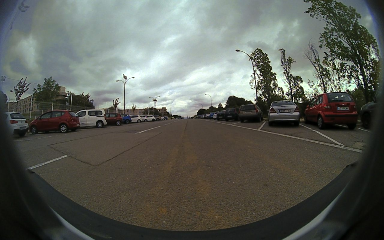

In [11]:
Image.open(conti_front_paths[0])

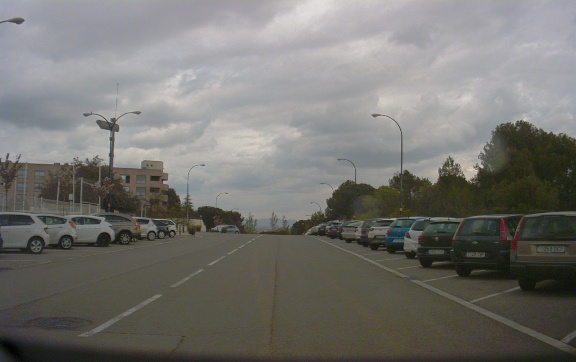

In [12]:
Image.open(sekonix_60_paths[0])

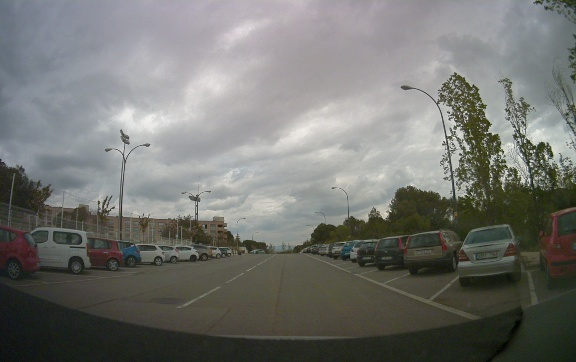

In [13]:
Image.open(sekonix_120_paths[0])

### K, now the SS predictions

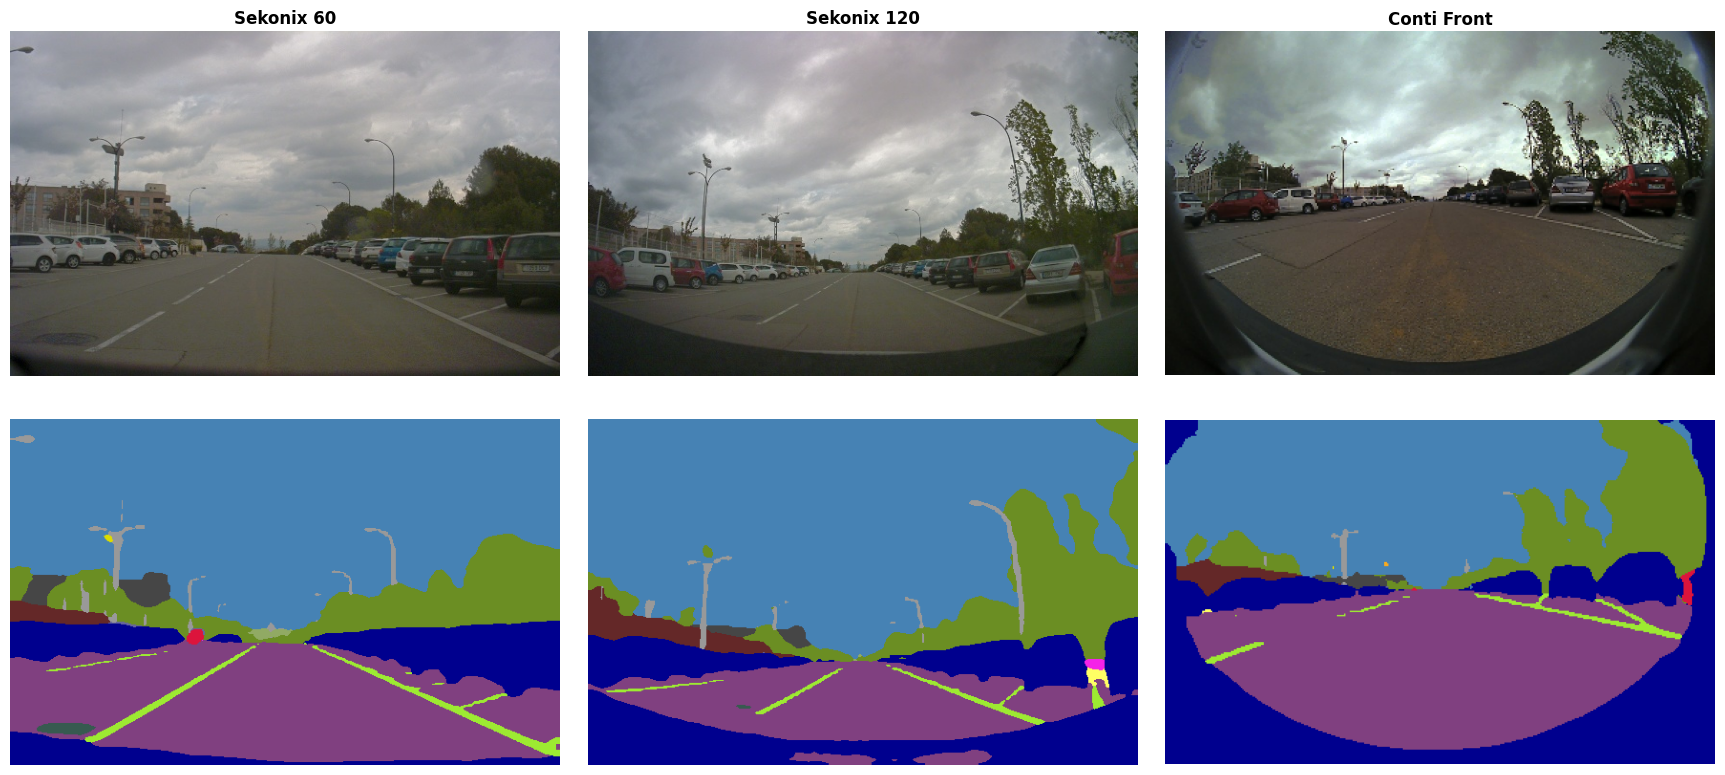

In [14]:
import matplotlib.pyplot as plt
from PIL import Image

def create_camera_visualization(idx=0):
    """Create a 2x3 grid showing camera images and their segmentations."""
    
    # Configuration
    camera_configs = [
        ("Sekonix 60", sekonix_60_paths),
        ("Sekonix 120", sekonix_120_paths), 
        ("Conti Front", conti_front_paths)
    ]
    
    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    
    # Remove spacing between subplots
    plt.subplots_adjust(hspace=0.02, wspace=0.05)
    
    for i, (camera_name, paths) in enumerate(camera_configs):
        top_ax, bottom_ax = axes[:, i]
        rgb_path = paths[idx]
        
        # Display original image
        top_ax.set_title(camera_name, fontsize=12, fontweight='bold', pad=5)
        top_ax.imshow(Image.open(rgb_path))
        top_ax.axis('off')
        
        # Generate and display segmentation
        segmentation = dtools.predict_segmentation(
            image_path=rgb_path,
            processor=processor,
            model=model,
            device=device
        )
        
        rgb_segmentation = dtools.mapillary_to_cityscapes_rgb(segmentation)
        bottom_ax.imshow(rgb_segmentation)
        bottom_ax.axis('off')
    
    plt.show()

# Usage
create_camera_visualization(idx=0)

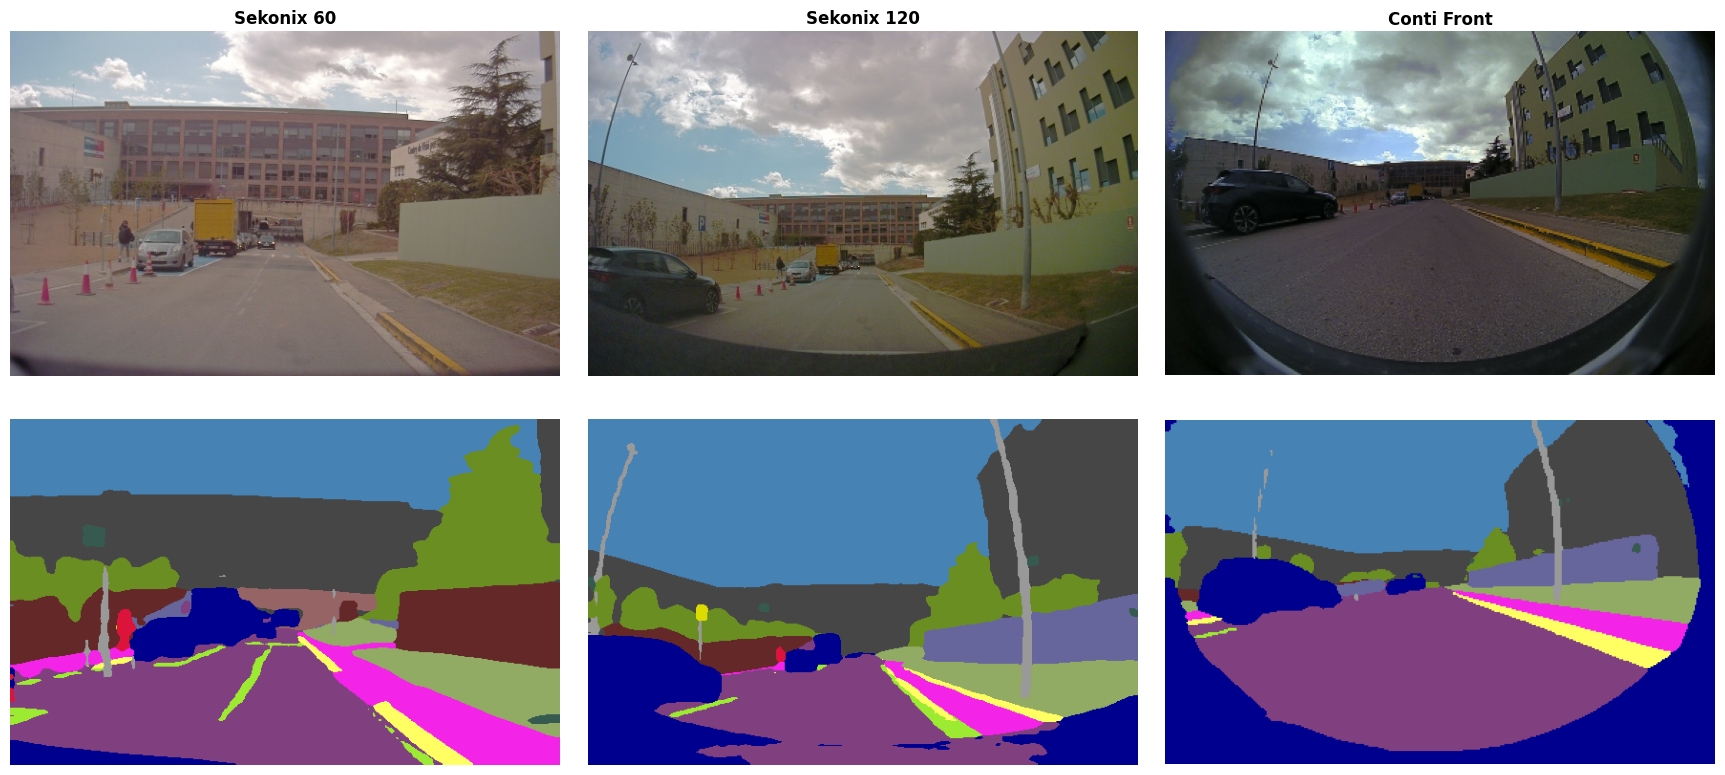

In [15]:
create_camera_visualization(idx=-1)

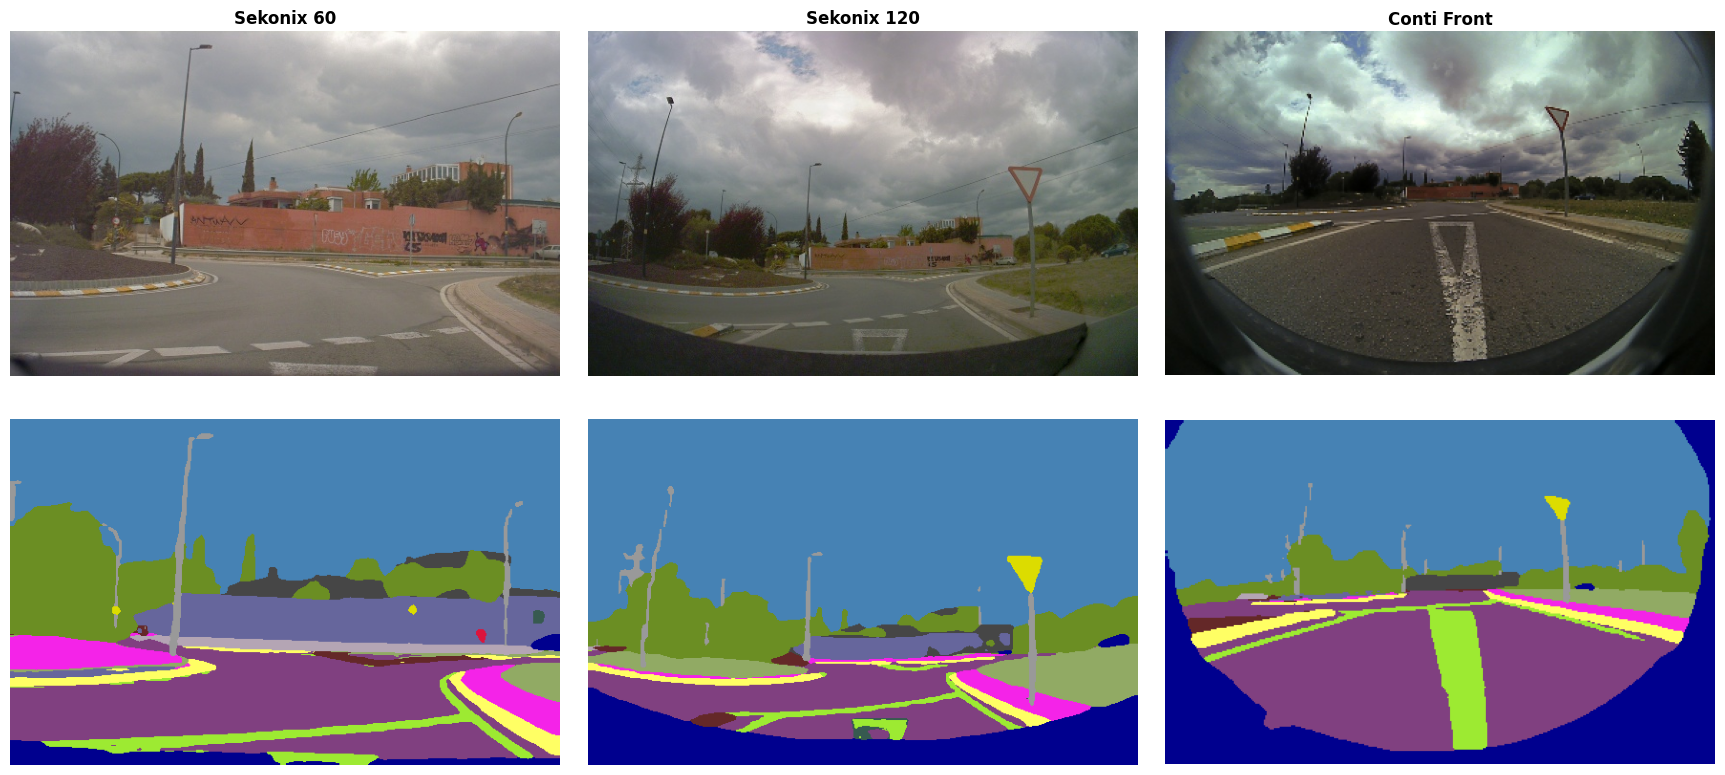

In [16]:
create_camera_visualization(idx=50000)

## Let's mask the ego vehicle's hood/body

In [15]:
from PIL import Image 

size_sekonix_60 = Image.open(sekonix_60_paths[0]).size
size_sekonix_120 = Image.open(sekonix_120_paths[0]).size
size_conti_front = Image.open(conti_front_paths[0]).size

mask_sekonix_60 = Image.open('./masks/mask_fov60.png').resize(size_sekonix_60).convert('L')
mask_sekonix_120 = Image.open('./masks/mask_fov120.png').resize(size_sekonix_120).convert('L')
mask_conti_front = Image.open('./masks/mask_conti_front.png').resize(size_conti_front).convert('L')

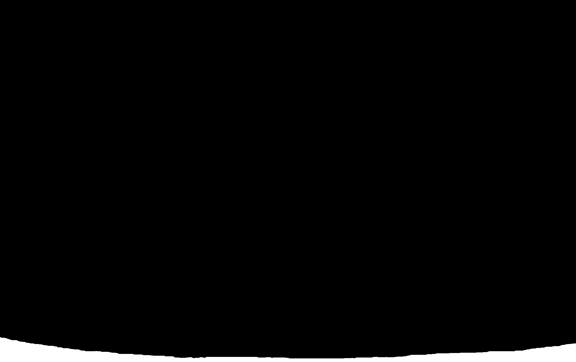

In [18]:
mask_sekonix_60

In [16]:
# Now, we multiply the segmentation by the masks to get the final segmentations; note the
# mask must be inverted, i.e., we want to remove the pixels of the hood

import numpy as np

def apply_mask_to_image(segmentation, mask):
    """Apply a mask to a segmentation image."""
    # Convert both images to numpy arrays
    seg_array = np.array(segmentation)
    mask_array = np.array(mask)[:,:, np.newaxis]  # Ensure mask has the same number of channels
    
    # Apply the mask (inverted)
    masked_image = seg_array * (mask_array == 0)
    
    return Image.fromarray(masked_image)

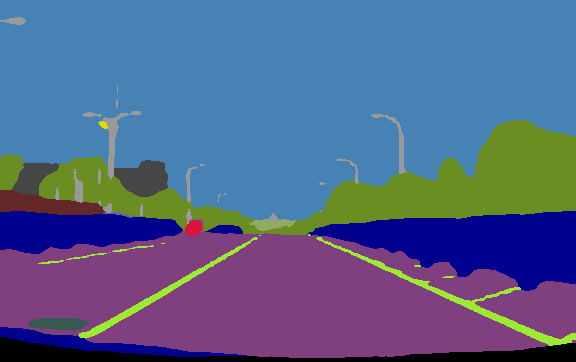

In [20]:
apply_mask_to_image(rgb_ss, mask_sekonix_60)

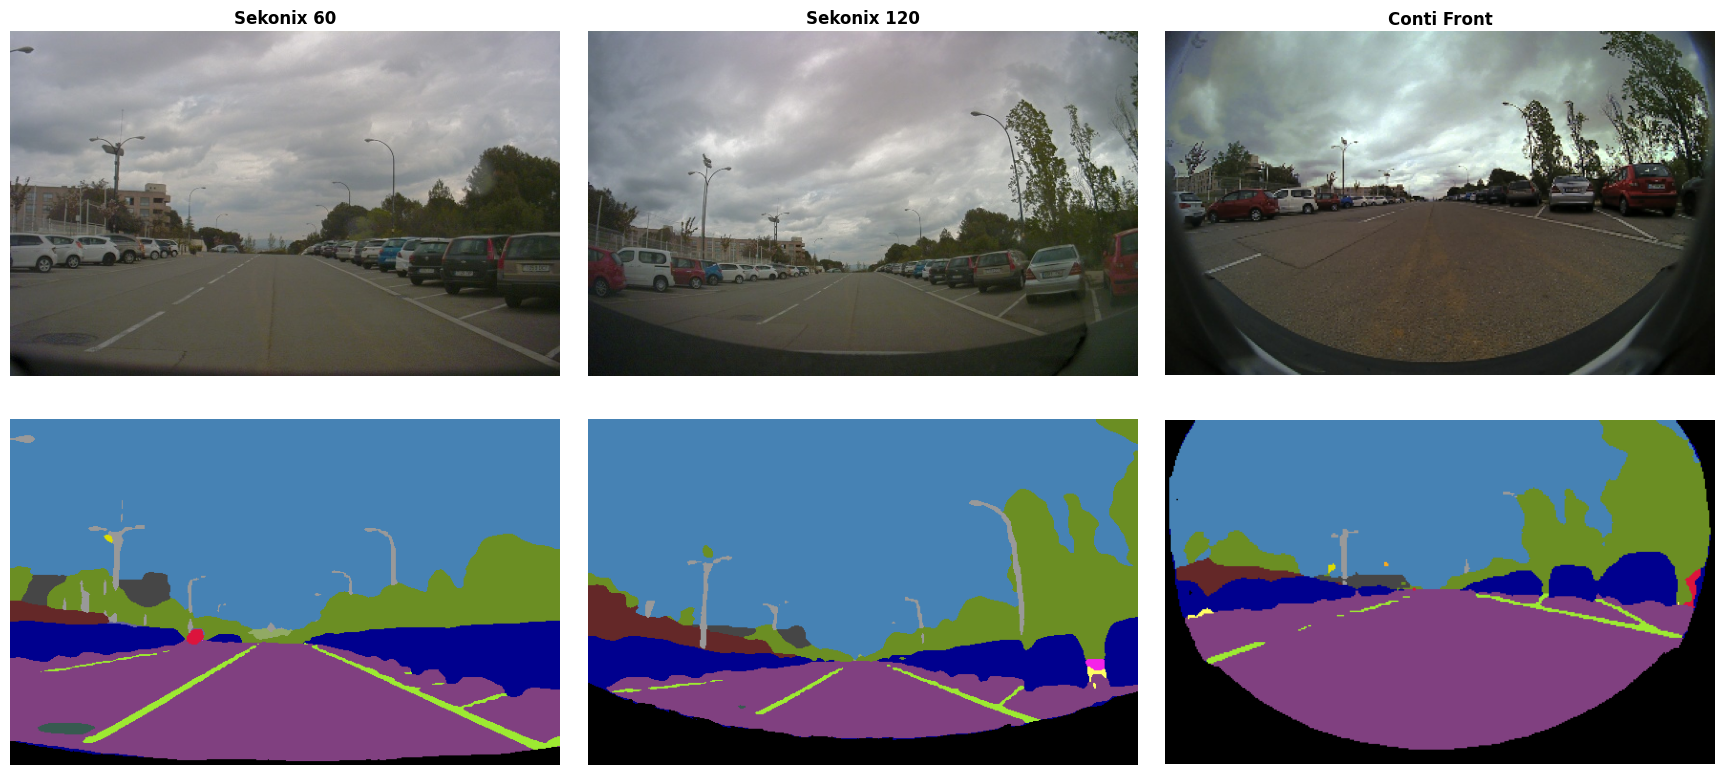

In [21]:
# Doesn't really work; perhaps apply the mask to the image first, then segment?

import matplotlib.pyplot as plt
from PIL import Image

def predict_segmentation(image_path: str,
                         processor: image_processing_mask2former.Mask2FormerImageProcessor,
                         model: modeling_mask2former.Mask2FormerForUniversalSegmentation,
                         device: str = 'cuda',
                         mask: Image = None) -> np.ndarray:
    # Mock prediction function: Replace with actual model prediction
    image = Image.open(image_path)
    if mask is not None:
        # Apply the mask to the image before processing
        image = apply_mask_to_image(image, mask)
    inputs = processor(images=image, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    # you can pass them to processor for postprocessing
    predicted_semantic_map = processor.post_process_semantic_segmentation(outputs, target_sizes=[image.size[::-1]])[0]

    return predicted_semantic_map.detach().cpu().numpy()

def create_camera_visualization(idx=0):
    """Create a 2x3 grid showing camera images and their segmentations."""
    
    # Configuration
    camera_configs = [
        ("Sekonix 60", sekonix_60_paths),
        ("Sekonix 120", sekonix_120_paths), 
        ("Conti Front", conti_front_paths)
    ]
    
    # Masks
    masks = {
        "Sekonix 60": mask_sekonix_60,
        "Sekonix 120": mask_sekonix_120,
        "Conti Front": mask_conti_front
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(22, 10))
    
    # Remove spacing between subplots
    plt.subplots_adjust(hspace=0.02, wspace=0.05)
    
    for i, (camera_name, paths) in enumerate(camera_configs):
        top_ax, bottom_ax = axes[:, i]
        rgb_path = paths[idx]
        
        # Display original image
        top_ax.set_title(camera_name, fontsize=12, fontweight='bold', pad=5)
        top_ax.imshow(Image.open(rgb_path))
        top_ax.axis('off')
        
        # Generate and display segmentation
        segmentation = predict_segmentation(
            image_path=rgb_path,
            processor=processor,
            model=model,
            device=device,
            mask=masks[camera_name]
        )
        
        rgb_segmentation = dtools.mapillary_to_cityscapes_rgb(segmentation)
        
        # Multiply by the mask
        rgb_segmentation = apply_mask_to_image(rgb_segmentation, masks[camera_name])
        
        bottom_ax.imshow(rgb_segmentation)
        bottom_ax.axis('off')
    
    plt.show()

# Usage
create_camera_visualization(idx=0)

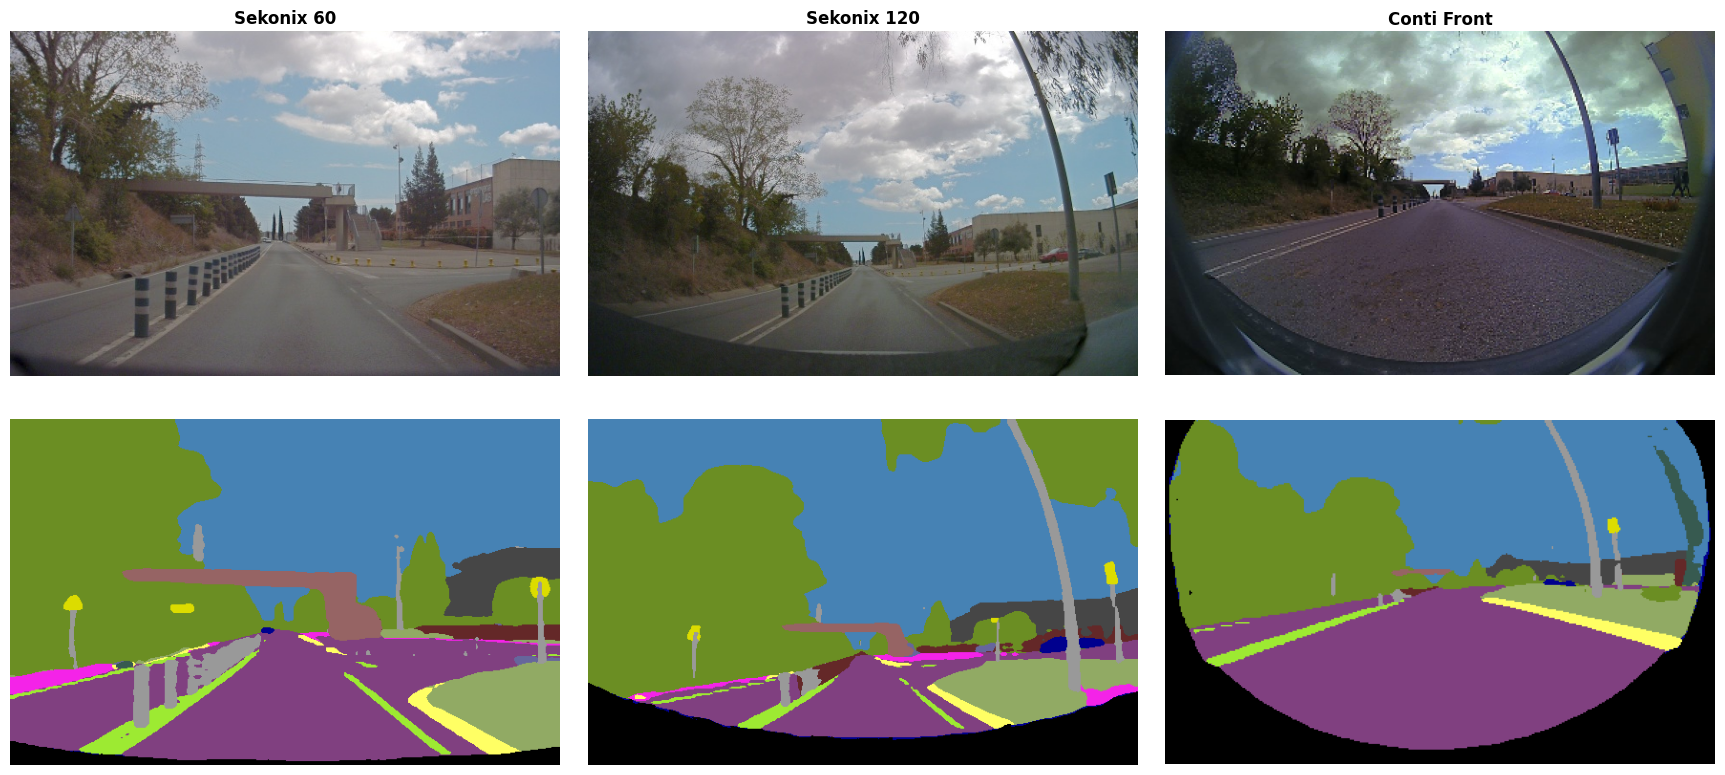

In [22]:
create_camera_visualization(idx=-180)

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm import tqdm
import tempfile
import shutil

def create_camera_visualization_frame_for_video(idx, save_path=None):
    """Create a single frame visualization and return as numpy array or save to file."""
    
    # Configuration
    camera_configs = [
        ("Sekonix 60", sekonix_60_paths),
        ("Sekonix 120", sekonix_120_paths), 
        ("Conti Front", conti_front_paths)
    ]
    
    # Masks
    masks = {
        "Sekonix 60": mask_sekonix_60,
        "Sekonix 120": mask_sekonix_120,
        "Conti Front": mask_conti_front
    }
    
    # Create figure with fixed size for consistent video dimensions
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # Reduced size for faster processing
    fig.patch.set_facecolor('black')
    
    # Remove spacing between subplots
    plt.subplots_adjust(hspace=0.05, wspace=0.05)
    
    for i, (camera_name, paths) in enumerate(camera_configs):
        if idx >= len(paths):
            continue
            
        top_ax, bottom_ax = axes[:, i]
        rgb_path = paths[idx]
        
        # Display original image
        top_ax.set_title(camera_name, fontsize=10, fontweight='bold', pad=3, color='white')
        rgb_image = Image.open(rgb_path)
        top_ax.imshow(rgb_image)
        top_ax.axis('off')
        
        # Generate and display segmentation
        segmentation = predict_segmentation(
            image_path=rgb_path,
            processor=processor,
            model=model,
            device=device,
            mask=masks[camera_name]
        )
        
        rgb_segmentation = dtools.mapillary_to_cityscapes_rgb(segmentation)
        
        # Apply mask to segmentation
        rgb_segmentation = apply_mask_to_image(rgb_segmentation, masks[camera_name])
        
        bottom_ax.imshow(rgb_segmentation)
        bottom_ax.axis('off')
    
    if save_path:
        # Save to file
        plt.savefig(save_path, dpi=100, bbox_inches='tight', pad_inches=0.1, 
                   facecolor='black', edgecolor='none')
        plt.close(fig)
        return save_path
    else:
        # Convert to numpy array for direct video writing
        fig.canvas.draw()
        buf = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        plt.close(fig)
        # Convert RGB to BGR for OpenCV
        return cv2.cvtColor(buf, cv2.COLOR_RGB2BGR)

def generate_segmentation_video_simple(output_video_path='segmentation_video.mp4', 
                                     fps=10,
                                     start_frame=0,
                                     end_frame=None,
                                     method='direct'):
    """
    Generate MP4 video showing semantic segmentation for all frames.
    
    Args:
        output_video_path: Path where the output video will be saved
        fps: Frames per second for the output video
        start_frame: Starting frame index
        end_frame: Ending frame index (None for all frames)
        method: 'direct' (write frames directly) or 'files' (save intermediate files)
    """
    
    # Determine the number of frames to process
    min_frames = min(len(sekonix_60_paths), len(sekonix_120_paths), len(conti_front_paths))
    
    if end_frame is None:
        end_frame = min_frames
    else:
        end_frame = min(end_frame, min_frames)
    
    frame_indices = list(range(start_frame, end_frame))
    
    print(f"Processing {len(frame_indices)} frames from {start_frame} to {end_frame-1}...")
    
    if method == 'direct':
        # Method 1: Direct video writing (more memory efficient)
        
        # Process first frame to get video dimensions
        print("Processing first frame to determine video dimensions...")
        first_frame = create_camera_visualization_frame_for_video(frame_indices[0])
        height, width = first_frame.shape[:2]
        
        # Initialize video writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
        
        if not video_writer.isOpened():
            raise RuntimeError("Failed to open video writer")
        
        # Write first frame
        video_writer.write(first_frame)
        
        # Process remaining frames
        for idx in tqdm(frame_indices[1:], desc="Processing frames", initial=1, total=len(frame_indices)):
            try:
                frame = create_camera_visualization_frame_for_video(idx)
                video_writer.write(frame)
                
                # Optional: Clear matplotlib cache periodically to prevent memory buildup
                if idx % 50 == 0:
                    plt.close('all')
                    
            except Exception as e:
                print(f"Error processing frame {idx}: {e}")
                continue
        
        video_writer.release()
        
    else:
        # Method 2: Save intermediate files (more reliable, uses disk space)
        temp_dir = tempfile.mkdtemp()
        
        try:
            print("Saving frames to temporary files...")
            
            # Process and save all frames
            saved_frames = []
            for idx in tqdm(frame_indices, desc="Processing frames"):
                try:
                    frame_path = os.path.join(temp_dir, f'frame_{idx:06d}.png')
                    result = create_camera_visualization_frame_for_video(idx, save_path=frame_path)
                    if result:
                        saved_frames.append(frame_path)
                        
                    # Clear matplotlib cache periodically
                    if idx % 50 == 0:
                        plt.close('all')
                        
                except Exception as e:
                    print(f"Error processing frame {idx}: {e}")
                    continue
            
            if not saved_frames:
                raise ValueError("No frames were successfully processed!")
            
            print(f"Successfully processed {len(saved_frames)} frames")
            
            # Create video from saved frames
            print("Creating video from saved frames...")
            first_frame = cv2.imread(saved_frames[0])
            height, width = first_frame.shape[:2]
            
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            video_writer = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
            
            for frame_path in tqdm(saved_frames, desc="Writing video"):
                frame = cv2.imread(frame_path)
                if frame is not None:
                    video_writer.write(frame)
            
            video_writer.release()
            
        finally:
            # Clean up temporary files
            shutil.rmtree(temp_dir)
            print("Temporary files cleaned up")
    
    print(f"Video saved to: {output_video_path}")

# Simplified version for testing
def test_single_frame():
    """Test processing a single frame to debug issues."""
    print("Testing single frame processing...")
    
    try:
        frame = create_camera_visualization_frame_for_video(0)
        print(f"Frame shape: {frame.shape}")
        print("Single frame test successful!")
        
        # Save test frame as image
        cv2.imwrite('test_frame.png', frame)
        print("Test frame saved as 'test_frame.png'")
        
    except Exception as e:
        print(f"Error in single frame test: {e}")
        import traceback
        traceback.print_exc()

# Usage:
if __name__ == "__main__":
    # First, test a single frame
    test_single_frame()
    
    # Then generate video for a small subset first
    print("\nGenerating video for frames 0-10...")
    generate_segmentation_video_simple(
        output_video_path='test_segmentation_video.mp4',
        fps=25,  # Slower for testing
        start_frame=0,
        end_frame=10,  # Just 10 frames for testing
        method='files'  # Use 'direct' or 'files'
    )

Testing single frame processing...
Frame shape: (800, 1500, 3)
Single frame test successful!
Test frame saved as 'test_frame.png'

Generating video for frames 0-10...
Processing 10 frames from 0 to 9...
Saving frames to temporary files...


Processing frames: 100%|██████████| 10/10 [00:13<00:00,  1.37s/it]


Successfully processed 10 frames
Creating video from saved frames...


Writing video: 100%|██████████| 10/10 [00:00<00:00, 27.02it/s]

Temporary files cleaned up
Video saved to: test_segmentation_video.mp4
